# Step 4: Training a Deep Q-Network (DQN) Agent

This is the final and most important step. We will train a Deep Q-Network (DQN) agent to master our custom `TaxiDispatchEnvV3` environment.

A DQN uses a neural network to approximate the Q-function, which allows it to handle the enormous state space of our complex environment.

This notebook contains:
1.  **Replay Buffer**: A class to store and sample the agent's experiences.
2.  **DQN Agent**: A class that defines the neural network architecture and the learning algorithm.
3.  **Training Loop**: The main script to run the simulation and train the agent.
4.  **Visualization**: Code to plot the agent's performance.

**Note**: This notebook requires PyTorch. If you don't have it installed, you will need to install it.

In [ ]:
# It's recommended to run this in your terminal if you don't have PyTorch
# %pip install torch torchvision torchaudio
# %pip install tqdm

import torch
import numpy as np
import pandas as pd
import random
from collections import deque
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import our refactored classes
from src.environment import TaxiDispatchEnvV3
from src.agent import DQNAgent

# Set a random seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


## 1. Setup Environment and Agent

Now that our `TaxiDispatchEnvV3` and `DQNAgent` classes are neatly organized in the `src` directory, we can simply import them.

This notebook now serves as the main "driver" script. It's responsible for:
1.  Instantiating the environment and the agent.
2.  Running the training loop.
3.  Evaluating the agent's performance against a baseline.
4.  Visualizing the results.


In [ ]:
# --- Hyperparameters ---
NUM_TAXIS = 50
DATA_PATH = 'data/yellow_tripdata_2025-01_manhattan.parquet'
MATRIX_PATH = 'data/travel_matrix.parquet'
EPISODE_LENGTH = 250 # Number of dispatch decisions per episode

# --- Environment and Agent Initialization ---
env = TaxiDispatchEnvV3(
    num_taxis=NUM_TAXIS,
    data_path=DATA_PATH,
    matrix_path=MATRIX_PATH,
    episode_length=EPISODE_LENGTH
)

# We need to know the number of unique locations for the DQN input layer
num_locations = len(env.unique_locations)

# Initialize DQN Agent
agent = DQNAgent(
    num_taxis=NUM_TAXIS,
    num_locations=num_locations,
    seed=seed
)


## 2. Train the DQN Agent

Here is the main training loop. We'll train for a set number of episodes and use a decaying epsilon-greedy strategy for exploration.


In [ ]:
def train_dqn(n_episodes=2000, max_t=EPISODE_LENGTH, eps_start=1.0, eps_end=0.01, eps_decay=0.995):
    """
    Main training loop for the DQN agent.
    
    Params
    ======
        n_episodes (int): maximum number of training episodes
        max_t (int): maximum number of timesteps per episode
        eps_start (float): starting value of epsilon, for epsilon-greedy action selection
        eps_end (float): minimum value of epsilon
        eps_decay (float): multiplicative factor (per episode) for decreasing epsilon
    """
    scores = []                        # list containing scores from each episode
    scores_window = deque(maxlen=100)  # last 100 scores
    eps = eps_start                    # initialize epsilon
    
    pbar = tqdm(range(1, n_episodes + 1))
    for i_episode in pbar:
        state, _ = env.reset()
        score = 0
        for t in range(max_t):
            action = agent.act(state, eps)
            next_state, reward, done, _, _ = env.step(action)
            agent.step(state, action, reward, next_state, done)
            state = next_state
            score += reward
            if done:
                break 
        
        scores_window.append(score)
        scores.append(score)
        
        eps = max(eps_end, eps_decay * eps) # decrease epsilon
        
        # Update the learning rate
        agent.scheduler.step()
        
        pbar.set_description(f"Episode {i_episode} | Avg Score: {np.mean(scores_window):.2f}")
        
        if i_episode % 100 == 0:
            print(f'\\rEpisode {i_episode}\\tAverage Score: {np.mean(scores_window):.2f}')
            
    # Save the trained model
    torch.save(agent.qnetwork_local.state_dict(), 'checkpoint.pth')
    return scores

# --- Start Training ---
scores = train_dqn()

# --- Visualize Results ---
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Score (Profit)')
plt.xlabel('Episode #')
plt.title('DQN Agent Training Performance')
plt.show()


## 3. Evaluate Agent Against a Baseline

Training is not enough. We need to prove our agent is better than a simple, naive strategy. Here, we'll define two baseline agents:

1.  **Random Agent**: Dispatches a random available taxi for every request.
2.  **Closest Agent**: A heuristic agent that always dispatches the taxi with the shortest "deadhead" distance to the pickup location.

We will run a series of evaluation episodes for our trained DQN agent and the baselines, then compare their performance on key metrics.


In [ ]:
def evaluate_agent(agent, env, n_episodes=100, is_dqn=False):
    """Runs an agent through the environment and returns total rewards."""
    total_rewards = []
    
    for i in tqdm(range(n_episodes), desc=f"Evaluating {agent.__class__.__name__}"):
        state, _ = env.reset()
        episode_reward = 0
        done = False
        
        while not done:
            if is_dqn:
                # DQN agent uses its learned policy (no exploration)
                action = agent.act(state, eps=0.0)
            else:
                # Baseline agents have a different act method signature
                action = agent.act(state)
                
            next_state, reward, done, _, _ = env.step(action)
            episode_reward += reward
            state = next_state
            
        total_rewards.append(episode_reward)
        
    return total_rewards

class RandomAgent:
    """A baseline agent that chooses actions randomly."""
    def __init__(self, num_taxis):
        self.num_taxis = num_taxis
        
    def act(self, state):
        return random.choice(np.arange(self.num_taxis))

class ClosestAgent:
    """A heuristic agent that chooses the closest taxi."""
    def __init__(self, env):
        self.env = env

    def act(self, state):
        taxi_locs = state['taxis']
        request_origin = state['request']['origin']
        day = state['time']['day_of_week']
        hour = state['time']['hour_of_day']
        
        min_dist = float('inf')
        best_taxi = -1
        
        for i, taxi_loc_idx in enumerate(taxi_locs):
            # Convert index back to LocationID for the travel cost function
            taxi_loc_id = self.env.inverse_location_map[taxi_loc_idx]
            request_origin_id = self.env.inverse_location_map[request_origin]
            
            dist = self.env._get_travel_cost(taxi_loc_id, request_origin_id, day, hour)
            
            if dist < min_dist:
                min_dist = dist
                best_taxi = i
                
        return best_taxi

# --- Initialize Baseline Agents ---
random_agent = RandomAgent(NUM_TAXIS)
closest_agent = ClosestAgent(env) # Needs env to access the travel matrix

# --- Load the Trained DQN Agent ---
# Make sure to load the state dict into a fresh agent instance
trained_agent = DQNAgent(num_taxis=NUM_TAXIS, num_locations=num_locations, seed=seed)
trained_agent.qnetwork_local.load_state_dict(torch.load('checkpoint.pth'))

# --- Run Evaluation ---
dqn_rewards = evaluate_agent(trained_agent, env, n_episodes=500, is_dqn=True)
random_rewards = evaluate_agent(random_agent, env, n_episodes=500)
closest_rewards = evaluate_agent(closest_agent, env, n_episodes=500)

# --- Print and Plot Results ---
print(f"\\n--- Evaluation Results ---")
print(f"DQN Agent Average Profit: ${np.mean(dqn_rewards):.2f}")
print(f"Closest Taxi Agent Average Profit: ${np.mean(closest_rewards):.2f}")
print(f"Random Agent Average Profit: ${np.mean(random_rewards):.2f}")

# Create a boxplot to compare distributions
plt.figure(figsize=(10, 6))
plt.boxplot([dqn_rewards, closest_rewards, random_rewards], labels=['DQN Agent', 'Closest Taxi', 'Random'])
plt.ylabel('Total Profit per Episode ($)')
plt.title('Agent Performance Comparison')
plt.grid(True)
plt.show()


In [ ]:
# --- Hyperparameters ---
NUM_TAXIS = 5
DATA_PATH = 'data/yellow_tripdata_2025-01_manhattan.parquet'
MATRIX_PATH = 'data/travel_matrix.parquet'
EPISODE_LENGTH = 50
INITIAL_LR = 5e-4

# --- Instantiate Environment and Agent ---
env = TaxiDispatchEnvV3(num_taxis=NUM_TAXIS, data_path=DATA_PATH, matrix_path=MATRIX_PATH, episode_length=EPISODE_LENGTH)
agent = DQNAgent(num_taxis=NUM_TAXIS, num_locations=len(env.unique_locations), seed=0, initial_lr=INITIAL_LR)

# --- Training ---
n_episodes = 2000
max_t = EPISODE_LENGTH # Set max_t to the episode length
eps_start = 1.0
eps_end = 0.01
eps_decay = 0.995

scores = []
scores_window = deque(maxlen=100)
eps = eps_start
best_avg_score = -np.inf # Initialize with a very low value

for i_episode in tqdm(range(1, n_episodes+1)):
    state, _ = env.reset()
    score = 0
    for t in range(max_t):
        action = agent.act(state, eps)
        next_state, reward, done, _, _ = env.step(action)
        agent.step(state, action, reward, next_state, done)
        state = next_state
        score += reward
        if done:
            break 
    scores_window.append(score)
    scores.append(score)
    eps = max(eps_end, eps_decay*eps)
    
    # Take a step with the learning rate scheduler
    agent.scheduler.step()
    
    current_avg_score = np.mean(scores_window)
    
    if i_episode % 100 == 0:
        print(f'\rEpisode {i_episode}\tAverage Score: {current_avg_score:.2f}')
        
    # Save the best model
    if current_avg_score > best_avg_score and len(scores_window) >= 100:
        print(f'New best average score of {current_avg_score:.2f} achieved at episode {i_episode}! Saving model...')
        torch.save(agent.qnetwork_local.state_dict(), 'checkpoint.pth')
        best_avg_score = current_avg_score


print(f'Training complete. Best average score: {best_avg_score:.2f}')

  5%|▌         | 102/2000 [00:04<01:19, 23.92it/s]

Episode 100	Average Score: 292.02


 10%|█         | 204/2000 [00:08<01:19, 22.67it/s]

Episode 200	Average Score: 304.72


 15%|█▌        | 303/2000 [00:12<01:17, 21.99it/s]

...

Episode 1800	Average Score: 364.17


 95%|█████████▌| 1902/2000 [01:29<00:04, 20.96it/s]

Episode 1900	Average Score: 361.88


100%|██████████| 2000/2000 [01:34<00:00, 21.19it/s]

Episode 2000	Average Score: 356.55
Training complete.


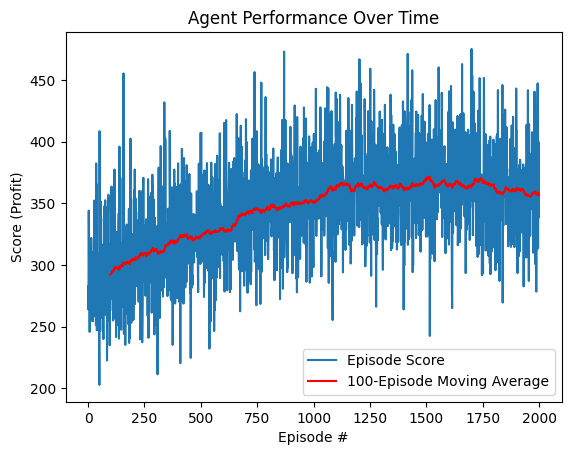

In [9]:
# Plot the scores
fig = plt.figure()
ax = fig.add_subplot(111)

# Plot raw scores
plt.plot(np.arange(len(scores)), scores, label='Episode Score')

# Calculate and plot 100-episode moving average
moving_avg = pd.Series(scores).rolling(100).mean()
plt.plot(moving_avg.index, moving_avg.values, color='red', label='100-Episode Moving Average')

plt.ylabel('Score (Profit)')
plt.xlabel('Episode #')
plt.title('Agent Performance Over Time')
plt.legend()
plt.show()